# LSTM 기반 주가예측모델

## 시계열 데이터 분석 Time Series Data
시계열 데이터란 **시간의 흐름에 따라 관찰하거나 측정한 데이터**를 말한다. 이 데이터는 일반적으로 시간의 순서를 가지며, 특정 시점에서의 값을 나타낸다. 예를 들어, 일일 주식 가격, 시간별 기온, 월별 매출 등이 시계열 데이터의 대표적인 예이다.

**주요 특징**
1. **시간 순서**  
   - 데이터가 시간의 흐름에 따라 정렬되어 있어야 한다. 시간의 순서가 데이터를 분석할 때 중요한 기준이 된다.
2. **시간 종속성**  
   - 이전 시점의 데이터가 이후 시점의 데이터에 영향을 미칠 수 있다.
3. **패턴과 추세**  
   - 주기적인 패턴(계절성)이나 장기적인 변화(추세)를 포함할 수 있다.
4. **불확실성**  
   - 시계열 데이터는 종종 노이즈(잡음)를 포함하며, 예측이 어려울 수 있다.

**활용**
- **금융**: 주식 가격, 환율 변동
- **기상**: 기온, 강수량 예측
- **경제**: GDP, 실업률 변화
- **소비자 행동**: 웹사이트 방문 트래픽, 제품 판매 데이터

**분석 및 모델링 방법**
- **EDA (탐색적 데이터 분석)**  
  - 데이터 시각화, 계절성, 추세 확인
- **통계적 모델링**  
  - ARIMA, SARIMA 등
- **머신러닝**  
  - 시계열 데이터에 특화된 RNN, LSTM, Transformer 등을 활용

시계열 데이터는 과거 데이터를 기반으로 미래를 예측하거나 현재의 상태를 분석하는 데 중요한 역할을 한다.

In [1]:
%pip install finance-datareader

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------  9.7/9.9 MB 54.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 44.0 MB/s  0:00:00

   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------- ----------------------------- 1/4 [requests-file]
   -------------------- ------------------- 2/4 [plotly]
   ------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import FinanceDataReader as fdr

In [3]:
# 주가데이터 가져오기
# - 회사별 주식코드(ticker)
samsung_code = '005930'
samsung = fdr.DataReader(samsung_code)
# Open 시가
# High 고가
# Low 저가
# Close 종가
# Volume 거래량
# Change 전날대비 변화량
samsung

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2013-11-04,29840,30040,29780,29980,217756,NaN
2013-11-05,30040,30040,29440,29700,160186,-0.009340
2013-11-06,29959,29959,28979,29020,244368,-0.022896
2013-11-07,29020,29080,28500,28740,260136,-0.009649
2013-11-08,28220,28560,28140,28200,273627,-0.018789
...,...,...,...,...,...,...
2026-01-16,145300,149500,144300,148900,30000219,0.034746
2026-01-19,147200,150600,146600,149300,22762497,0.002686
2026-01-20,148500,149300,143900,145200,24059218,-0.027461


In [4]:
apple = fdr.DataReader('AAPL')
apple = fdr.DataReader('AAPL', '2017-01-01', '2017-12-31')
apple.tail()

,Open,High,Low,Close,Volume,Adj Close
2017-12-22,43.669998,43.855000,43.625000,43.752499,65397600,40.985909
2017-12-26,42.700001,42.867500,42.419998,42.642502,132742000,39.946102
2017-12-27,42.525002,42.695000,42.427502,42.650002,85992800,39.953144
2017-12-28,42.750000,42.962502,42.619999,42.770000,65920800,40.065536
2017-12-29,42.630001,42.647499,42.305000,42.307499,103999600,39.632282


## 주식데이터 시각화

In [5]:
naver_code = '035420'
naver = fdr.DataReader(naver_code)
naver.index

DatetimeIndex(['2013-11-04', '2013-11-05', '2013-11-06', '2013-11-07',
               '2013-11-08', '2013-11-11', '2013-11-12', '2013-11-13',
               '2013-11-14', '2013-11-15',
               ...
               '2026-01-09', '2026-01-12', '2026-01-13', '2026-01-14',
               '2026-01-15', '2026-01-16', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22'],
              dtype='datetime64[ns]', name='Date', length=3000, freq=None)

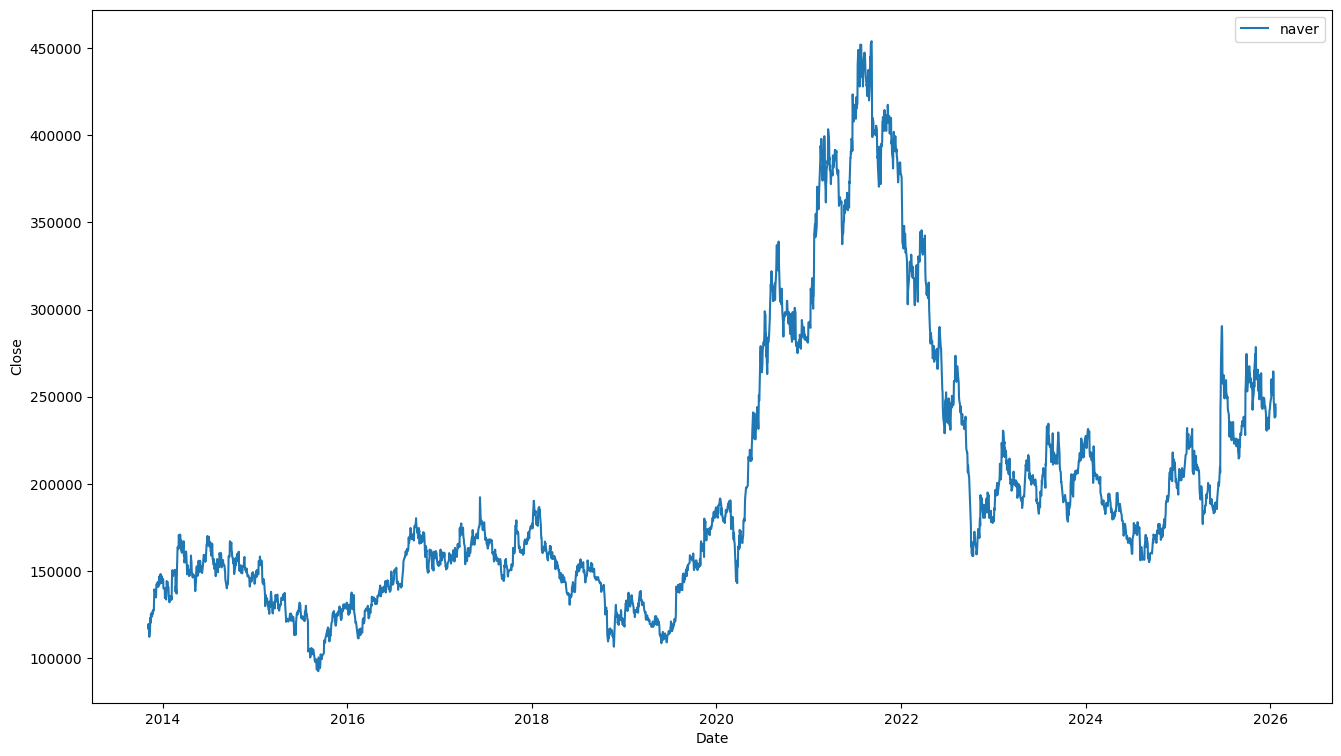

In [6]:
plt.figure(figsize=(16, 9))
plt.plot(naver.index, naver['Close'], label="naver")
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.show()

## 학습데이터 생성

In [7]:
from sklearn.preprocessing import MinMaxScaler

prices = naver['Close'].values

scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices.reshape(-1, 1)).flatten()
prices_scaled

array([0.06896332, 0.07505621, 0.06563892, ..., 0.419198  , 0.40398651,
       0.42334658], shape=(3000,))

In [8]:
def create_dataset(data, window_size=20):
    X, y = [], []

    for i in range(len(data) - window_size):
        inputs = data[i: i + window_size]
        label = data[i + window_size]
        X.append(inputs)
        y.append(label)

    return np.array(X), np.array(y)

X, y = create_dataset(prices_scaled)
X.shape, y.shape

((2980, 20), (2980,))

In [9]:
df = pd.DataFrame(X)
df['target'] = y
df

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,target
0,0.068963,0.075056,0.065639,0.067301,0.054562,0.065639,0.084474,0.076718,0.087798,0.091675,...,0.086689,0.093335,0.090566,0.096659,0.096659,0.096106,0.111616,0.129895,0.127680,0.124911
1,0.075056,0.065639,0.067301,0.054562,0.065639,0.084474,0.076718,0.087798,0.091675,0.090566,...,0.093335,0.090566,0.096659,0.096659,0.096106,0.111616,0.129895,0.127680,0.124911,0.124355
2,0.065639,0.067301,0.054562,0.065639,0.084474,0.076718,0.087798,0.091675,0.090566,0.086689,...,0.090566,0.096659,0.096659,0.096106,0.111616,0.129895,0.127680,0.124911,0.124355,0.117156
3,0.067301,0.054562,0.065639,0.084474,0.076718,0.087798,0.091675,0.090566,0.086689,0.093335,...,0.096659,0.096659,0.096106,0.111616,0.129895,0.127680,0.124911,0.124355,0.117156,0.118818
4,0.054562,0.065639,0.084474,0.076718,0.087798,0.091675,0.090566,0.086689,0.093335,0.090566,...,0.096659,0.096106,0.111616,0.129895,0.127680,0.124911,0.124355,0.117156,0.118818,0.137650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2975,0.384626,0.383244,0.381861,0.395689,0.402604,0.399838,0.398455,0.384626,0.413667,0.415049,...,0.434409,0.463450,0.442707,0.438558,0.446855,0.451004,0.475895,0.462067,0.428878,0.423347
2976,0.383244,0.381861,0.395689,0.402604,0.399838,0.398455,0.384626,0.413667,0.415049,0.427495,...,0.463450,0.442707,0.438558,0.446855,0.451004,0.475895,0.462067,0.428878,0.423347,0.402604
2977,0.381861,0.395689,0.402604,0.399838,0.398455,0.384626,0.413667,0.415049,0.427495,0.434409,...,0.442707,0.438558,0.446855,0.451004,0.475895,0.462067,0.428878,0.423347,0.402604,0.419198
2978,0.395689,0.402604,0.399838,0.398455,0.384626,0.413667,0.415049,0.427495,0.434409,0.463450,...,0.438558,0.446855,0.451004,0.475895,0.462067,0.428878,0.423347,0.402604,0.419198,0.403987


In [10]:
# 텐서 변환
import torch

X_tensor = torch.tensor(X, dtype=torch.float).unsqueeze(-1)
y_tensor = torch.tensor(y, dtype=torch.float).unsqueeze(-1)
X_tensor.shape, y_tensor.shape

(torch.Size([2980, 20, 1]), torch.Size([2980, 1]))

In [11]:
# 학습/검증 분리
train_size = int(len(X_tensor) * 0.8)
X_train, X_val = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_val = y_tensor[:train_size], y_tensor[train_size:]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

torch.Size([2384, 20, 1]) torch.Size([2384, 1])
torch.Size([596, 20, 1]) torch.Size([596, 1])


## Conv1d 레이어

<img src="https://controlandlearning.wordpress.com/wp-content/uploads/2020/07/figure-1.png" width="500"/>

**1. Conv1d란?**

`nn.Conv1d`는 1차원 시퀀스 데이터를 위한 합성곱 레이어이다.  
예: 시계열 데이터, 텍스트 임베딩 등

**2. 입력/출력 형태**

- 입력 shape: `(batch_size, in_channels, seq_len)`
- 출력 shape: `(batch_size, out_channels, new_seq_len)`

**3. 주요 파라미터**

| 파라미터           | 설명                                        |
| -------------- | ----------------------------------------- |
| `in_channels`  | 입력 채널 수 (예: 임베딩 차원, 또는 이전 conv의 출력 채널 수)  |
| `out_channels` | 출력 채널 수 (필터 개수, convolution 결과 feature 수) |
| `kernel_size`  | 필터 크기 (한 번에 보는 시점의 개수)                    |
| `stride`       | 필터가 이동하는 간격 (기본값=1)                       |
| `padding`      | 입력 시퀀스 앞뒤에 0을 덧붙여서 시퀀스 길이를 조절 (기본값=0)     |


**4.출력길이 계산**

- L: 원래 시퀀스 길이

```
output_length = floor((L + 2 * padding - kernel_size) / stride) + 1
```
위 이미지에서는 패딩이 없으므로 `(5 + 2 * 0 - 2) / 1 + 1 = 4`로 처리

In [12]:
# con1d 구조
import torch
import torch.nn as nn

x = torch.randn(1, 20, 1) # (batch_size, seq_len, input_size)
print('입력:', x.shape)

conv1d = nn.Conv1d(
    in_channels=1,
    out_channels=32, # 필터(커널수)
    kernel_size=5,
    padding=4
)

x = x.permute(0, 2, 1)
print('in 차원변환:', x.shape)
# conv1d 요구사항:  (batch_size, input_size, seq_len)
x = conv1d(x)
print('conv1d출력:', x.shape)
x = x.permute(0, 2, 1)
print('out 차원변환:', x.shape)


입력: torch.Size([1, 20, 1])
in 차원변환: torch.Size([1, 1, 20])
conv1d출력: torch.Size([1, 32, 24])
out 차원변환: torch.Size([1, 24, 32])


## 모델 생성

In [13]:
import torch.nn as nn

class StockLSTM(nn.Module):

    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            conv_filters,
            conv_kernel_size):
        super().__init__()
        self.conv1d = nn.Conv1d(input_size,
                                conv_filters,
                                kernel_size=conv_kernel_size,
                                padding=conv_kernel_size - 1)
        self.lstm = nn.LSTM(conv_filters, hidden_size,
                            num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x = (batch_size, seq_len, input_size)
        x = x.permute(0, 2, 1)
        x = self.conv1d(x) # (batch_size, channels, seq_len)
        x = x.permute(0, 2, 1)
        _, (hidden, _) = self.lstm(x)
        output = self.fc1(hidden[-1])
        output = self.relu(output)
        output = self.fc2(output)
        return output



## 모델 학습

In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = StockLSTM(input_size=1,
                  hidden_size=64,
                  num_layers=2,
                  conv_filters=32,
                  conv_kernel_size=5).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)


# 학습
epochs = 50
batch_size = 32

for epoch in range(epochs):
    model.train()
    # 데이터 순서 섞기
    permutation = torch.randperm(X_train.size()[0])
    train_loss = 0

    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i : i + batch_size]
        X_batch = X_train[indices].to(device)
        y_batch = y_train[indices].to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 검증
    model.eval()
    with torch.no_grad():
        X_val = X_val.to(device)
        y_val = y_val.to(device)
        output = model(X_val)
        loss = criterion(output, y_val)
        val_loss = loss.item()

    print(f'Epoch {epoch + 1}/{epochs}: '
          f'Train Loss {train_loss:.6f}, '
          f'Val Loss {val_loss:.6f}')

Epoch 1/50: Train Loss 0.513632, Val Loss 0.000611
Epoch 2/50: Train Loss 0.034708, Val Loss 0.000381
Epoch 3/50: Train Loss 0.040171, Val Loss 0.000328
Epoch 4/50: Train Loss 0.025999, Val Loss 0.000330
Epoch 5/50: Train Loss 0.025035, Val Loss 0.000290
Epoch 6/50: Train Loss 0.024960, Val Loss 0.000583
Epoch 7/50: Train Loss 0.041335, Val Loss 0.000277
Epoch 8/50: Train Loss 0.024422, Val Loss 0.000278
Epoch 9/50: Train Loss 0.024117, Val Loss 0.000253
Epoch 10/50: Train Loss 0.029209, Val Loss 0.000300
Epoch 11/50: Train Loss 0.037297, Val Loss 0.000496
Epoch 12/50: Train Loss 0.020671, Val Loss 0.000248
Epoch 13/50: Train Loss 0.018108, Val Loss 0.000431
Epoch 14/50: Train Loss 0.019289, Val Loss 0.000238
Epoch 15/50: Train Loss 0.019690, Val Loss 0.000219
Epoch 16/50: Train Loss 0.021376, Val Loss 0.000230
Epoch 17/50: Train Loss 0.024293, Val Loss 0.000221
Epoch 18/50: Train Loss 0.016998, Val Loss 0.000228
Epoch 19/50: Train Loss 0.022134, Val Loss 0.000288
Epoch 20/50: Train Lo

## 모델 예측/시각화

In [15]:
model.eval()
with torch.no_grad():
    X_val = X_val.to(device)
    output = model(X_val)
    pred = output.detach().cpu().numpy()

# 스케일복원
pred_inverse = scaler.inverse_transform(pred)
y_val = y_val.detach().cpu().numpy()
y_val_inverse = scaler.inverse_transform(y_val)

pred_inverse[-1], y_val_inverse[-1]

(array([237535.64], dtype=float32), array([245499.98], dtype=float32))

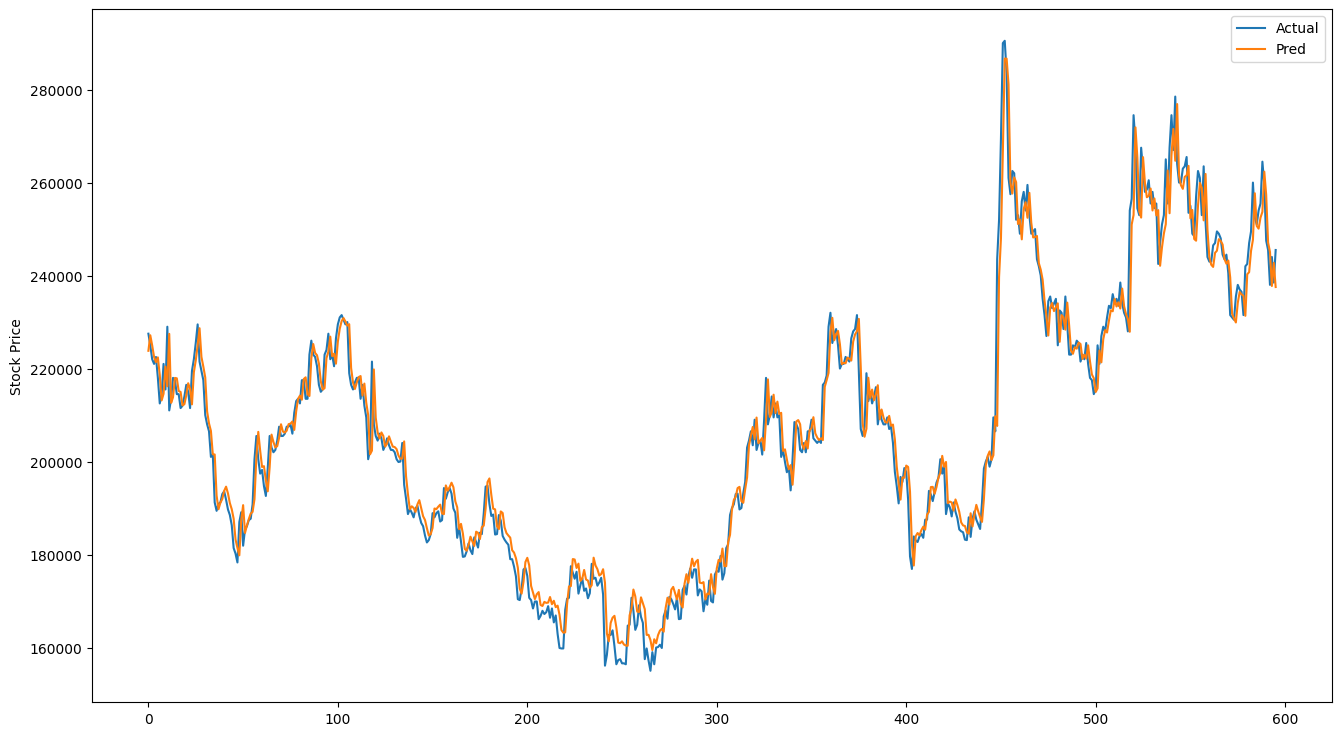

In [16]:
plt.figure(figsize=(16, 9))
plt.plot(y_val_inverse, label='Actual')
plt.plot(pred_inverse, label='Pred')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

## 모델 예측

In [17]:
# 모델 예측
def predict_next_stock_price(data, model, scaler, device):
    # 스케일링
    data_scaled = scaler.transform(data.reshape(-1, 1))
    # 텐서변환
    data_tensor = torch.tensor(data_scaled, dtype=torch.float).unsqueeze(0)
    data_tensor = data_tensor.to(device)
    print(data_tensor.shape)
    # 모델예측
    model.eval()
    with torch.no_grad():
        output = model(data_tensor)
        pred = output.detach().cpu().numpy()

    # 역스케일링
    pred_inverse = scaler.inverse_transform(pred)
    return pred_inverse[-1]

data = naver['Close'].values[-20:] # ndarray
pred_price = predict_next_stock_price(data, model, scaler, device)
pred_price

torch.Size([1, 20, 1])


array([243908.8], dtype=float32)